<a href="https://colab.research.google.com/github/divyasri-jonnadula-16/spoken-language-identification/blob/main/HuBert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torchaudio datasets scikit-learn -q

In [ ]:
import os
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
from transformers import HubertModel, Wav2Vec2FeatureExtractor
import torch.nn as nn
from sklearn.metrics import classification_report

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
label_map = {
    "english": 0,
    "german": 1,
    "spanish": 2
}

In [ ]:
class LanguageDataset(Dataset):

    def __init__(self, root_dir):
        self.files = []
        self.labels = []

        for lang in os.listdir(root_dir):
            lang_path = os.path.join(root_dir, lang)

            for file in os.listdir(lang_path):
                if file.endswith(".flac") or file.endswith(".wav"):
                    self.files.append(os.path.join(lang_path, file))
                    self.labels.append(label_map[lang])

        self.feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
            "facebook/hubert-base-ls960"
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        audio_path = self.files[idx]
        label = self.labels[idx]

        waveform, sr = torchaudio.load(audio_path)

        if sr != 16000:
            waveform = torchaudio.functional.resample(waveform, sr, 16000)

        waveform = waveform.squeeze()

        inputs = self.feature_extractor(
            waveform,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        input_values = inputs.input_values.squeeze(0)

        return input_values, label

In [ ]:
def collate_fn(batch):

    inputs = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch])

    inputs = torch.nn.utils.rnn.pad_sequence(inputs, batch_first=True)

    return inputs, labels

In [ ]:
train_dataset = LanguageDataset("/content/drive/MyDrive/spokenvoice/train")
test_dataset = LanguageDataset("/content/drive/MyDrive/spokenvoice/test")

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

In [ ]:
class HubertClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.hubert = HubertModel.from_pretrained("facebook/hubert-base-ls960")

        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )

    def forward(self, x):

        outputs = self.hubert(x)

        hidden = outputs.last_hidden_state

        pooled = hidden.mean(dim=1)

        logits = self.classifier(pooled)

        return logits

In [ ]:
model = HubertClassifier().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=2e-5
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

In [ ]:
from torch.utils.data import random_split

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

In [ ]:
EPOCHS = 10
patience = 5

best_val_loss = float('inf')
counter = 0

for epoch in range(EPOCHS):

    # -------- TRAINING --------
    model.train()
    total_loss = 0

    for audio, labels in train_loader:

        audio = audio.to(device)
        labels = labels.to(device)

        outputs = model(audio)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)


    # -------- VALIDATION --------
    model.eval()
    val_loss = 0

    with torch.no_grad():

        for audio, labels in val_loader:

            audio = audio.to(device)
            labels = labels.to(device)

            outputs = model(audio)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


    # -------- EARLY STOPPING --------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_hubert_model.pth")

        print("Validation improved. Model saved.")

    else:

        counter += 1
        print(f"No improvement ({counter}/{patience})")

        if counter >= patience:
            print("Early stopping triggered!")
            break


# Load best model after training
model.load_state_dict(torch.load("best_hubert_model.pth"))

Epoch 1/10 | Train Loss: 0.2242 | Val Loss: 0.2997
Validation improved. Model saved.
Epoch 2/10 | Train Loss: 0.0551 | Val Loss: 0.0022
Validation improved. Model saved.
Epoch 3/10 | Train Loss: 0.0296 | Val Loss: 0.0029
No improvement (1/5)
Epoch 4/10 | Train Loss: 0.0082 | Val Loss: 0.0009
Validation improved. Model saved.
Epoch 5/10 | Train Loss: 0.0090 | Val Loss: 0.0154
No improvement (1/5)
Epoch 6/10 | Train Loss: 0.0138 | Val Loss: 0.0002
Validation improved. Model saved.
Epoch 7/10 | Train Loss: 0.0036 | Val Loss: 0.0001
Validation improved. Model saved.
Epoch 8/10 | Train Loss: 0.0011 | Val Loss: 0.0001
Validation improved. Model saved.
Epoch 9/10 | Train Loss: 0.0100 | Val Loss: 0.0001
No improvement (1/5)
Epoch 10/10 | Train Loss: 0.0140 | Val Loss: 0.0001
Validation improved. Model saved.


<All keys matched successfully>

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for audio, labels in test_loader:

        audio = audio.to(device)

        outputs = model(audio)

        preds = torch.argmax(outputs, dim=1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=["English","German","Spanish"]
))

              precision    recall  f1-score   support

     English       1.00      1.00      1.00       180
      German       1.00      0.99      1.00       180
     Spanish       0.99      1.00      1.00       180

    accuracy                           1.00       540
   macro avg       1.00      1.00      1.00       540
weighted avg       1.00      1.00      1.00       540



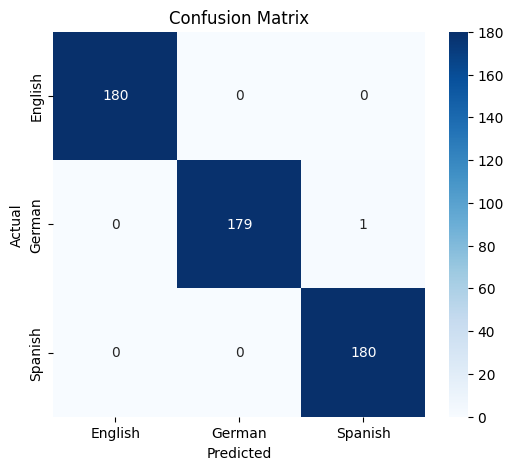

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["English","German","Spanish"],
    yticklabels=["English","German","Spanish"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 5400
Test samples: 540


In [ ]:
import os

languages = ["english", "german", "spanish"]

for lang in languages:

    train_path = f"/content/drive/MyDrive/spokenvoice/train/{lang}"
    test_path = f"/content/drive/MyDrive/spokenvoice/test/{lang}"

    train_files = set(os.listdir(train_path))
    test_files = set(os.listdir(test_path))

    duplicates = train_files.intersection(test_files)

    print(f"{lang.upper()} duplicate files:", len(duplicates))

ENGLISH duplicate files: 0
GERMAN duplicate files: 0
SPANISH duplicate files: 0


different names but same audio

In [ ]:
import hashlib
import os

def file_hash(filepath):
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

languages = ["english","german","spanish"]

for lang in languages:

    train_path = f"/content/drive/MyDrive/spokenvoice/train/{lang}"
    test_path = f"/content/drive/MyDrive/spokenvoice/test/{lang}"

    train_hashes = set()

    for file in os.listdir(train_path):
        train_hashes.add(file_hash(os.path.join(train_path,file)))

    duplicate_count = 0

    for file in os.listdir(test_path):
        if file_hash(os.path.join(test_path,file)) in train_hashes:
            duplicate_count += 1

    print(f"{lang.upper()} duplicate audio files:", duplicate_count)

ENGLISH duplicate audio files: 0
GERMAN duplicate audio files: 0
SPANISH duplicate audio files: 0
